In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [12]:
# ---- Input files: (machine, workflow) -> path ----
FILES = {
    ("Intel i5", "chipseq"): "../../Processed_data/Experiments/intel_i5/chipseq/predicted/intel_chipseq_predictions_vs_actual.csv",
    ("Intel i5", "atacseq"): "../../Processed_data/Experiments/intel_i5/atacseq/predicted/intel_i5_atacseq_predictions_vs_actual.csv",
    ("Ryzen 7", "chipseq"): "../../Processed_data/Experiments/AMD_Ryzen7/chipseq/predicted/ryzen7_chipseq_predictions_vs_actual.csv",
    ("Ryzen 7", "atacseq"): "../../Processed_data/Experiments/AMD_Ryzen7/atacseq/predicted/ryzen7_atacseq_predictions_vs_actual.csv",
    ("Ryzen 5", "chipseq"): "../../Processed_data/Experiments/AMD_Ryzen5/chipseq/predicted/ryzen5_chipseq_predictions_vs_actual.csv",
    ("Ryzen 5", "atacseq"): "../../Processed_data/Experiments/AMD_Ryzen5/atacseq/predicted/ryzen5_atacseq_predictions_vs_actual.csv",
}
ORDER = ["Intel i5", "Ryzen 7", "Ryzen 5"]
POWER = {"Intel i5": "~44 W", "Ryzen 7": "~28 W", "Ryzen 5": "~23 W"}


def load(fn):
    """Load a prediction file, returning measured (m) and predicted (p) energy."""
    d = pd.read_csv(fn)
    m = "measured_energy_j" if "measured_energy_j" in d.columns else "energy_j"
    d = d[[m, "predicted_energy_j"]].rename(columns={m: "m", "predicted_energy_j": "p"}).dropna()
    return d[(d.m > 0) & (d.p > 0)]


# Pool both workflows per machine
machines = {}
for (mach, wf), fn in FILES.items():
    machines.setdefault(mach, []).append(load(fn))
machines = {k: pd.concat(v, ignore_index=True) for k, v in machines.items()}

# Per-machine calibration factor: median(measured/predicted), seed-averaged over 200 splits
factors = {}
for mach, d in machines.items():
    fs = [(d.sample(frac=0.1, random_state=s).pipe(lambda c: (c.m / c.p).median()))
          for s in range(200)]
    factors[mach] = float(np.median(fs))



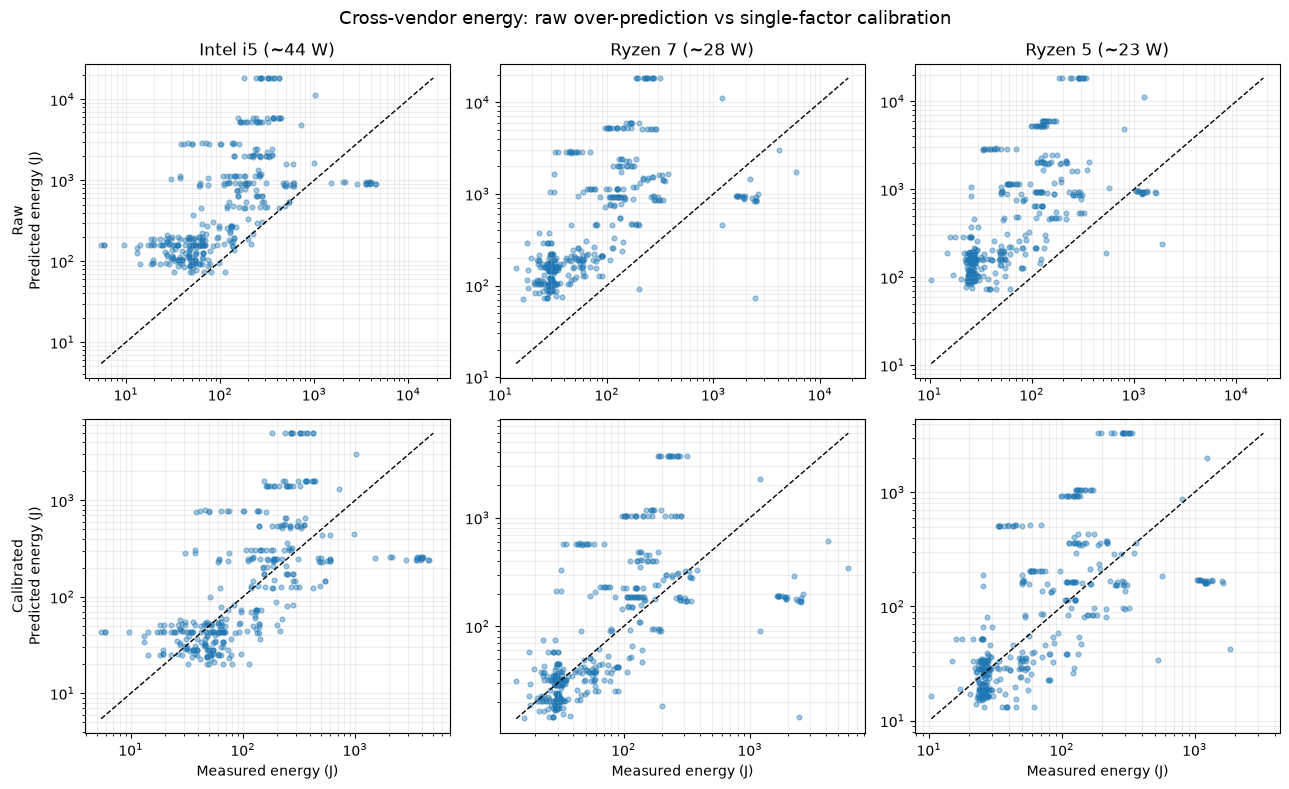

In [13]:
# ================= FIGURE 1: predicted vs measured, raw vs calibrated =================
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for j, mach in enumerate(ORDER):
    d, f = machines[mach], factors[mach]
    for i, (mode, pred) in enumerate([("Raw", d.p), ("Calibrated", d.p * f)]):
        ax = axes[i, j]
        ax.scatter(d.m, pred, s=12, alpha=0.4, color="#1f77b4")
        lo, hi = min(d.m.min(), pred.min()), max(d.m.max(), pred.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)           # y = x
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.grid(True, which="both", alpha=0.2)
        if i == 0: ax.set_title(f"{mach} ({POWER[mach]})")
        if j == 0: ax.set_ylabel(f"{mode}\nPredicted energy (J)")
        if i == 1: ax.set_xlabel("Measured energy (J)")
fig.suptitle("Cross-vendor energy: raw over-prediction vs single-factor calibration", fontsize=13)
fig.tight_layout()
fig.savefig("fig_crossvendor_scatter.png", dpi=150, bbox_inches="tight")
plt.show()




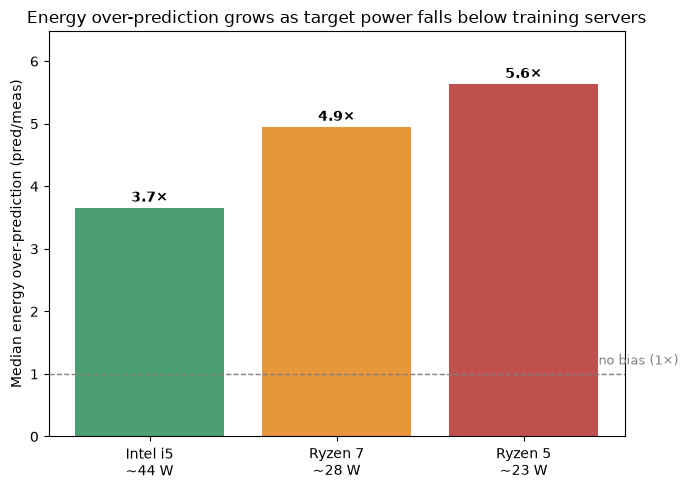

In [14]:
# ================= FIGURE 2: over-prediction ratio by machine power =================
ratios = {m: (machines[m].p / machines[m].m).median() for m in ORDER}
fig, ax = plt.subplots(figsize=(7, 5))
vals = [ratios[m] for m in ORDER]
bars = ax.bar([f"{m}\n{POWER[m]}" for m in ORDER], vals,
              color=["#4C9F70", "#E8963A", "#C0504D"])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.1, f"{v:.1f}×", ha="center", fontweight="bold")
ax.axhline(1.0, ls="--", color="gray", lw=1)
ax.text(2.4, 1.15, "no bias (1×)", color="gray", fontsize=9)
ax.set_ylabel("Median energy over-prediction (pred/meas)")
ax.set_title("Energy over-prediction grows as target power falls below training servers")
ax.set_ylim(0, max(vals) * 1.15)
fig.tight_layout()
fig.savefig("fig_overprediction_by_power.png", dpi=150, bbox_inches="tight")
plt.show()




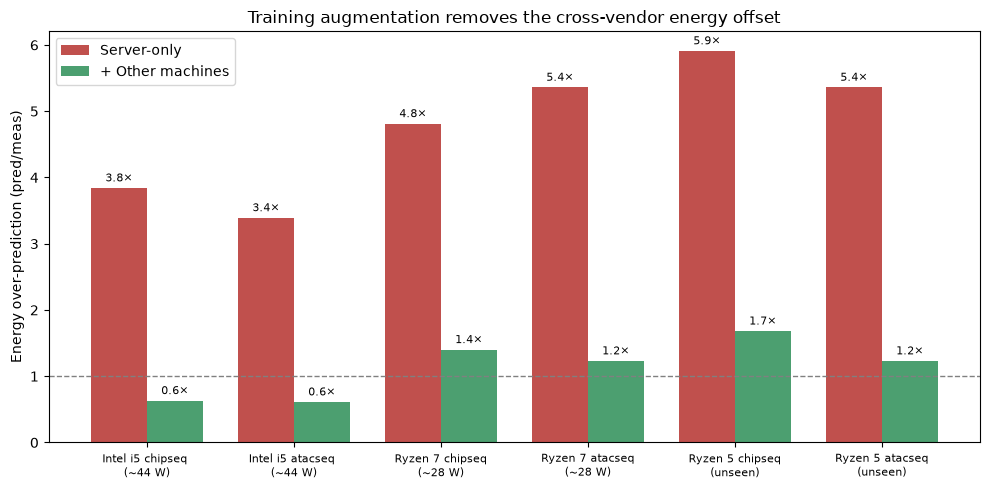

In [15]:
# ================= FIGURE 3: training-augmentation before/after (from Table 7.3) =================
aug = [  # (label, server_only, augmented)
    ("Intel i5 chipseq \n(~44 W)", 3.84, 0.63),
    ("Intel i5 atacseq \n(~44 W)", 3.39, 0.61),
    ("Ryzen 7 chipseq\n(~28 W)", 4.81, 1.40),
    ("Ryzen 7 atacseq\n(~28 W)", 5.36, 1.23),
    ("Ryzen 5 chipseq\n(unseen)", 5.91, 1.68),
    ("Ryzen 5 atacseq\n(unseen)", 5.36, 1.23),
]
labels = [a[0] for a in aug]
so = [a[1] for a in aug]
ag = [a[2] for a in aug]
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w / 2, so, w, label="Server-only", color="#C0504D")
b2 = ax.bar(x + w / 2, ag, w, label="+ Other machines", color="#4C9F70")
ax.axhline(1.0, ls="--", color="gray", lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Energy over-prediction (pred/meas)")
ax.set_title("Training augmentation removes the cross-vendor energy offset")
ax.legend()
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.1,
                f"{b.get_height():.1f}×", ha="center", fontsize=8)
fig.tight_layout()
fig.savefig("fig_augmentation.png", dpi=150, bbox_inches="tight")
plt.show()